# ReplaySAM Demo

This notebook loads the iron ore tomogram from `data/iron_ore_GOH6_500_1/sim_res_0/tomo_noisy.zarr`, previews a slice, generates candidate point prompts from local distance-transform maxima, and prepares a `SAM2PipelineConfig` for a real SAM2 run.


In [1]:
from pathlib import Path
import os
import sys


def find_repo_root(start: Path = Path.cwd()) -> Path:
    for path in (start, *start.parents):
        if (path / "pyproject.toml").exists() and (path / "replaysam").exists():
            return path
    raise RuntimeError("Could not find the ReplaySAM repository root.")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

INPUT_VOLUME_PATH = REPO_ROOT / "data" / "iron_ore_GOH6_500_1" / "sim_res_0" / "tomo_noisy.zarr"
OUTPUT_PARENT_DIR = REPO_ROOT / "notebooks" / "demo_outputs"
OUTPUT_PARENT_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(OUTPUT_PARENT_DIR / ".matplotlib"))

if not INPUT_VOLUME_PATH.exists():
    raise FileNotFoundError(f"Input volume not found: {INPUT_VOLUME_PATH}")

print(f"Repository root: {REPO_ROOT}")
print(f"Input volume:    {INPUT_VOLUME_PATH}")
print(f"Output parent:   {OUTPUT_PARENT_DIR}")


Repository root: /home/bg/Developer/ReplaySAM
Input volume:    /home/bg/Developer/ReplaySAM/data/iron_ore_GOH6_500_1/sim_res_0/tomo_noisy.zarr
Output parent:   /home/bg/Developer/ReplaySAM/notebooks/demo_outputs


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

from replaysam.models.adapters import SAM2BackboneAdapter
from replaysam.pipeline import Pipeline
from replaysam.utils.configs import (
    PromptGeneratorConfig,
    SAM2BackboneConfig,
    SAM2PipelineConfig,
)
from replaysam.utils.io import VolumeReader
from replaysam.utils.prompt_generator import PromptGenerator

plt.rcParams["figure.figsize"] = (6, 6)


## 1. Load the input tomogram


In [3]:
reader = VolumeReader(INPUT_VOLUME_PATH, chunks=(64, 256, 256))
dask_volume = reader.get_dask_array()
loaded_volume = reader.get_numpy_array()

print(dask_volume)
print(
    f"Loaded NumPy array: shape={loaded_volume.shape}, "
    f"dtype={loaded_volume.dtype}, "
    f"range=({np.nanmin(loaded_volume):.3f}, {np.nanmax(loaded_volume):.3f})"
)


dask.array<from-zarr, shape=(1024, 1024, 1024), dtype=uint8, chunksize=(64, 256, 256), chunktype=numpy.ndarray>
Loaded NumPy array: shape=(1024, 1024, 1024), dtype=uint8, range=(0.000, 234.000)


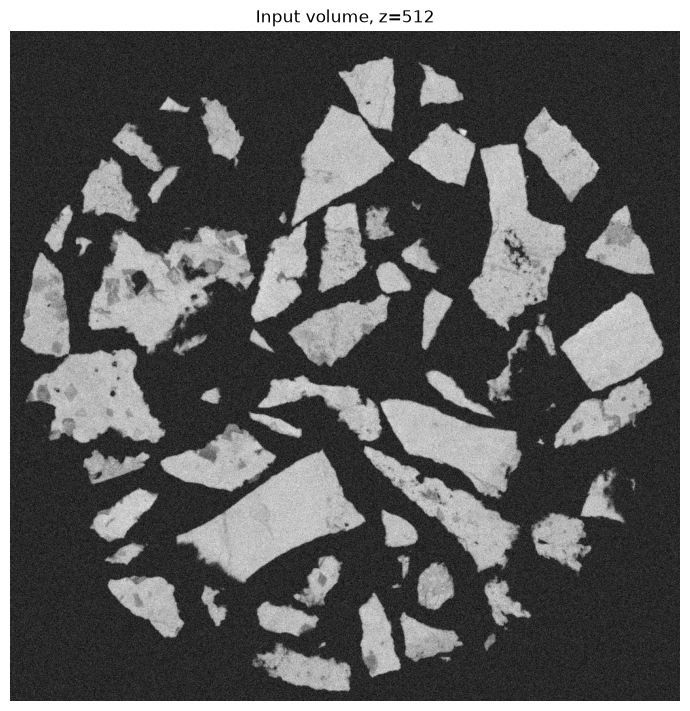

In [4]:
z_slice = loaded_volume.shape[0] // 2

fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True)
ax.imshow(loaded_volume[z_slice], cmap="gray")
ax.set_title(f"Input volume, z={z_slice}")
ax.axis("off");


## 2. Generate candidate point prompts


In [4]:
prompt_config = PromptGeneratorConfig(
    binarisation_threshold=None,
    dist_val_thresh=5.0,
    max_filter_size=7,
    crop_size=(256, 256, 256),
    crop_overlap=(32, 32, 32),
)

prompt_generator = PromptGenerator(tomo=loaded_volume)
prompt_coords, prompt_values = prompt_generator.generate_peak_local_max_prompts(
    crop_size=prompt_config.crop_size,
    crop_overlap=prompt_config.crop_overlap,
    bin_thresh=prompt_config.binarisation_threshold,
    dist_val_thresh=prompt_config.dist_val_thresh,
    max_filter_size=prompt_config.max_filter_size,
    show_progress=True,
    return_max_values=True,
)

print(f"Generated {len(prompt_coords)} prompts")
for idx, (coord, value) in enumerate(zip(prompt_coords[:20], prompt_values[:20], strict=True), start=1):
    print(f"{idx:02d}. zyx={tuple(int(v) for v in coord)}  distance={value:.2f}")


Generating prompts from local maxima: 100%|██████████| 125/125 [00:08<00:00, 15.26it/s]


Generated 18703 prompts
01. zyx=(927, 794, 255)  distance=73.56
02. zyx=(768, 224, 231)  distance=54.53
03. zyx=(924, 944, 590)  distance=52.25
04. zyx=(824, 768, 448)  distance=52.00
05. zyx=(282, 336, 479)  distance=50.56
06. zyx=(291, 393, 565)  distance=50.41
07. zyx=(564, 691, 927)  distance=49.00
08. zyx=(294, 424, 611)  distance=48.38
09. zyx=(742, 224, 180)  distance=47.44
10. zyx=(769, 769, 436)  distance=46.03
11. zyx=(581, 234, 289)  distance=45.94
12. zyx=(270, 292, 404)  distance=45.31
13. zyx=(479, 202, 703)  distance=43.56
14. zyx=(578, 208, 351)  distance=43.38
15. zyx=(673, 824, 296)  distance=43.31
16. zyx=(350, 868, 562)  distance=42.25
17. zyx=(703, 686, 224)  distance=42.09
18. zyx=(860, 849, 282)  distance=41.09
19. zyx=(479, 185, 255)  distance=40.97
20. zyx=(720, 820, 270)  distance=40.91


In [ ]:
fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True)
ax.imshow(loaded_volume[z_slice], cmap="gray")

if len(prompt_coords):
    near_slice = np.abs(prompt_coords[:, 0] - z_slice) <= 2
    if np.any(near_slice):
        ax.scatter(
            prompt_coords[near_slice, 2],
            prompt_coords[near_slice, 1],
            s=80,
            marker="x",
            c="tab:red",
            linewidths=2,
            label="Prompt within +/-4 z slices",
        )
        ax.legend(loc="upper right")

ax.set_title(f"Prompt locations near z={z_slice}")
ax.axis("off");


## 3. Build a ReplaySAM pipeline config


In [5]:
pipeline_config = SAM2PipelineConfig(
    volume_path=INPUT_VOLUME_PATH,
    output_parent_dir=OUTPUT_PARENT_DIR / "pipeline_outputs",
    backbone_config=SAM2BackboneConfig(
        model_size="tiny",
        compute_device="cuda:0",
        storage_device="cpu",
        compile=False,
    ),
    prompt_generator_config=prompt_config,
    max_prompts=10,
    inference_axes=(0, 1, 2),
    majority_voting_threshold=2,
    note="Demo config for the iron ore GOH6 tomogram.",
)

display(pipeline_config.as_dict())


{'volume_path': '/home/bg/Developer/ReplaySAM/data/iron_ore_GOH6_500_1/sim_res_0/tomo_noisy.zarr',
 'output_parent_dir': '/home/bg/Developer/ReplaySAM/notebooks/demo_outputs/pipeline_outputs',
 'backbone_config': {'model_size': 'tiny',
  'apply_postprocessing': True,
  'compile': False,
  'compute_device': 'cuda:0',
  'storage_device': 'cpu',
  'n_sample_points': 3,
  'pred_iou_thresh': 0.8,
  'termination_iou': 0.7,
  'termination_mask_size': 20},
 'prompt_generator_config': {'binarisation_threshold': None,
  'dist_val_thresh': 5.0,
  'max_filter_size': 7,
  'crop_size': [256, 256, 256],
  'crop_overlap': [32, 32, 32]},
 'max_prompts': 10,
 'postprocess_mask_size_threshold': 100,
 'postprocess_overlap_ratio_threshold': 0.6,
 'inference_axes': [0, 1, 2],
 'majority_voting_threshold': 2,
 'note': 'Demo config for the iron ore GOH6 tomogram.'}

## 4. Run one prompt through the adapter

This uses the first prompt from the prompt generator and calls `SAM2BackboneAdapter.run_multi_axes_inference(...)` directly with axes `(0, 1, 2)`.


Selected first prompt: zyx=(927, 794, 255), distance=73.56


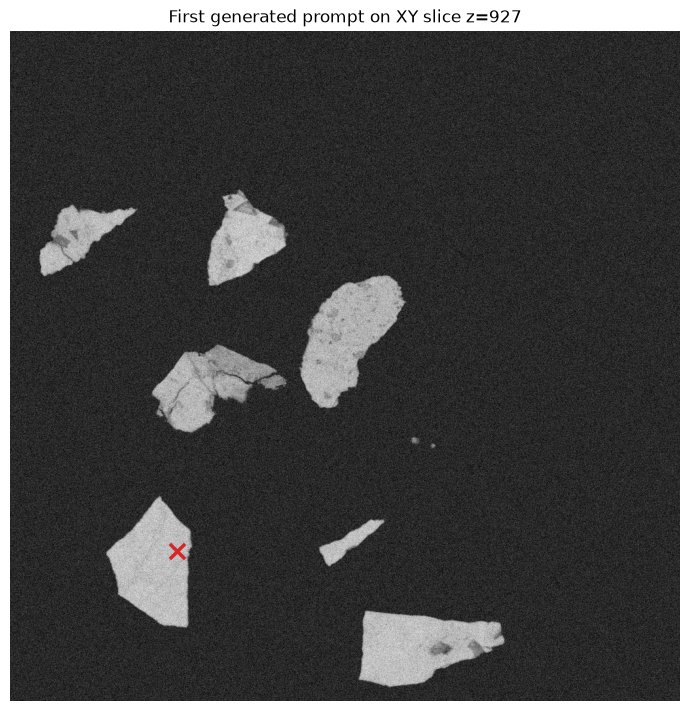

In [8]:
if len(prompt_coords) == 0:
    raise RuntimeError("Prompt generator returned no prompts; tune prompt_config before running adapter inference.")

point_prompt = tuple(int(v) for v in prompt_coords[0])
point_value = float(prompt_values[0])
prompt_z, prompt_y, prompt_x = point_prompt

print(f"Selected first prompt: zyx={point_prompt}, distance={point_value:.2f}")

fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True)
ax.imshow(loaded_volume[prompt_z], cmap="gray")
ax.scatter(
    [prompt_x],
    [prompt_y],
    s=120,
    marker="x",
    c="tab:red",
    linewidths=2.5,
)
ax.set_title(f"First generated prompt on XY slice z={prompt_z}")
ax.axis("off");


In [11]:
import importlib.util
import torch

# if importlib.util.find_spec("sam2") is None:
#     raise RuntimeError(
#         "The vendored SAM2 package is not importable in this kernel. "
#         "Install it with: uv pip install -e replaysam/models/sam2"
#     )

compute_device = pipeline_config.backbone_config.compute_device
if str(compute_device).startswith("cuda") and not torch.cuda.is_available():
    raise RuntimeError(
        f"pipeline_config requests {compute_device}, but CUDA is not visible to this kernel."
    )

adapter = SAM2BackboneAdapter(
    backbone_config=pipeline_config.backbone_config,
    volume=loaded_volume,
)

with torch.autocast('cuda', dtype=torch.bfloat16):
    single_prompt_result = adapter.run_multi_axes_inference(
        point_prompt=point_prompt,
        dist_map_val=point_value,
        axes=(0, 1, 2),
        majority_voting_threshold=pipeline_config.majority_voting_threshold,
    )

print(f"Adapter result offset: {single_prompt_result.offset}")
print(f"Adapter result shape:  {single_prompt_result.volume.shape}")
print(f"Positive voxels:       {int(np.count_nonzero(single_prompt_result.volume))}")


/home/bg/Developer/ReplaySAM/replaysam/models/sam2_backbone.py:859: UserWarning: cannot import name '_C' from 'sam2' (/home/bg/Developer/ReplaySAM/replaysam/models/sam2/__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  low_res_masks = fill_holes_in_mask_scores(
Forward Propagation at axis 0:  34%|███▍      | 33/97 [00:01<00:02, 29.54it/s]

Adapter result offset: (741, 713, 133)
Adapter result shape:  (270, 268, 287)
Positive voxels:       3245424


## 5. Inspect five stepped slices along each axis


axis 0 / XY: local slice indices [45, 90, 135, 180, 225] with step 45
axis 1 / XZ: local slice indices [46, 90, 134, 178, 222] with step 44
axis 2 / YZ: local slice indices [49, 96, 143, 190, 237] with step 47


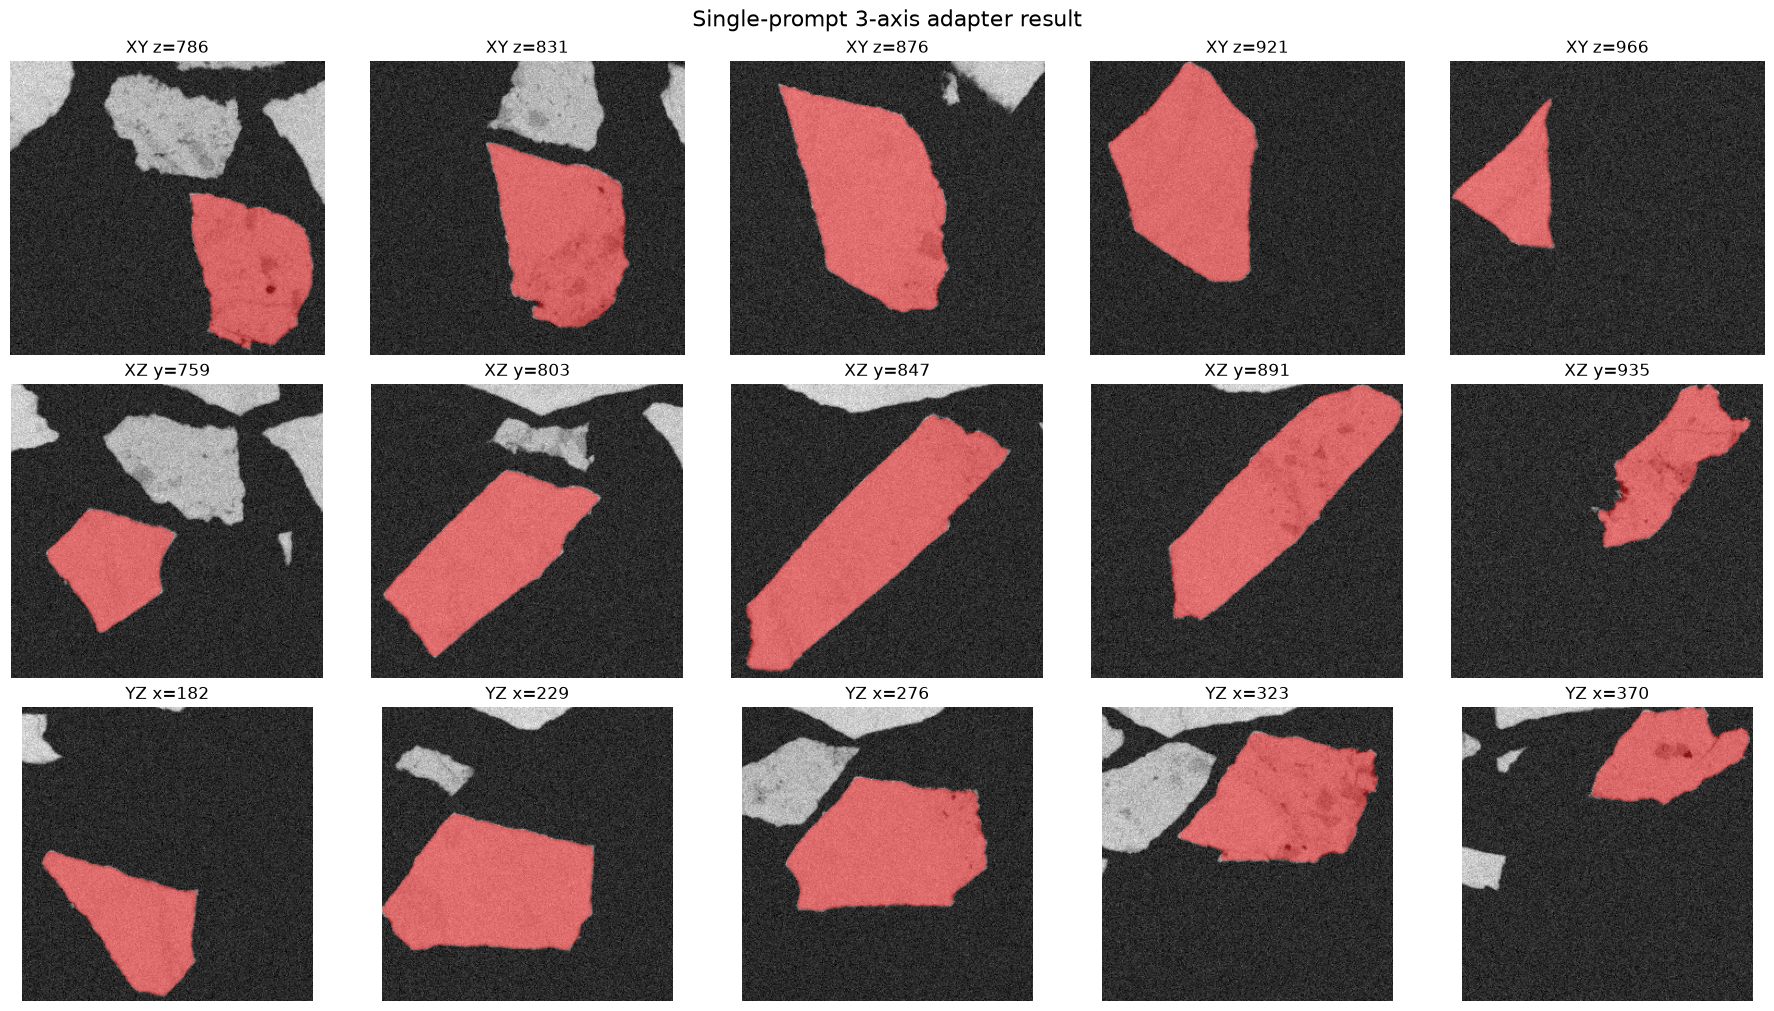

In [12]:
def five_stepped_indices(length: int, n_slices: int = 5) -> tuple[np.ndarray, int]:
    if length <= 0:
        return np.array([], dtype=int), 0
    if length <= n_slices:
        return np.arange(length, dtype=int), 1
    step = max(1, length // (n_slices + 1))
    start = max(0, (length - step * (n_slices - 1)) // 2)
    indices = start + step * np.arange(n_slices, dtype=int)
    return np.clip(indices, 0, length - 1), step


def axis_slice_pair(volume: np.ndarray, mask: np.ndarray, offset: tuple[int, int, int], axis: int, local_idx: int):
    z0, y0, x0 = offset
    dz, dy, dx = mask.shape
    if axis == 0:
        global_idx = z0 + local_idx
        image = volume[global_idx, y0:y0 + dy, x0:x0 + dx]
        mask_slice = mask[local_idx, :, :]
        label = f"XY z={global_idx}"
    elif axis == 1:
        global_idx = y0 + local_idx
        image = volume[z0:z0 + dz, global_idx, x0:x0 + dx]
        mask_slice = mask[:, local_idx, :]
        label = f"XZ y={global_idx}"
    elif axis == 2:
        global_idx = x0 + local_idx
        image = volume[z0:z0 + dz, y0:y0 + dy, global_idx]
        mask_slice = mask[:, :, local_idx]
        label = f"YZ x={global_idx}"
    else:
        raise ValueError(f"axis must be 0, 1, or 2; got {axis}")
    return image, mask_slice, label


mask = np.asarray(single_prompt_result.volume, dtype=bool)
if mask.size == 0 or not np.any(mask):
    raise RuntimeError("The single-prompt adapter result is empty; there are no slices to display.")

axis_names = {0: "axis 0 / XY", 1: "axis 1 / XZ", 2: "axis 2 / YZ"}
fig, axes = plt.subplots(3, 5, figsize=(18, 10), constrained_layout=True)

for axis in (0, 1, 2):
    local_indices, step = five_stepped_indices(mask.shape[axis], n_slices=5)
    print(f"{axis_names[axis]}: local slice indices {local_indices.tolist()} with step {step}")
    for col in range(5):
        ax = axes[axis, col]
        if col >= len(local_indices):
            ax.axis("off")
            continue
        image, mask_slice, label = axis_slice_pair(
            loaded_volume,
            mask,
            single_prompt_result.offset,
            axis,
            int(local_indices[col]),
        )
        ax.imshow(image, cmap="gray")
        ax.imshow(np.ma.masked_where(~mask_slice, mask_slice), cmap="autumn", alpha=0.45)
        ax.set_title(label)
        ax.axis("off")

fig.suptitle("Single-prompt 3-axis adapter result", fontsize=16);


The full pipeline below runs the complete prompt loop after the single-point adapter demo. Set `RUN_FULL_PIPELINE` to control whether this final step executes.


In [ ]:
RUN_FULL_PIPELINE = True

if RUN_FULL_PIPELINE:
    pipeline = Pipeline(pipeline_config)
    pipeline.run()
    print(f"Pipeline output: {pipeline.output_path}")
